# Техническая очистка


Проверим наборы данных проекта `college_majors_eda` на пропуски и логические несоответствия, а затем приведем признаки к форматам, пригодным для дальнейшего анализа.



## Загрузка библиотек и установка настроек


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)


## Введение констант


In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")

DATASET_FILES = {
    "majors_all_ages": RAW_DATA_DIR / "majors_all_ages.csv",
    "majors_degree_levels": RAW_DATA_DIR / "majors_degree_levels.csv",
    "majors_recent_graduates": RAW_DATA_DIR / "majors_recent_graduates.csv",
}


## Загрузка наборов данных


In [3]:
datasets = {name: pd.read_csv(path) for name, path in DATASET_FILES.items()}


### Проверка согласованности ключей между таблицами


In [4]:
major_code_sets = {name: set(df["Major_code"]) for name, df in datasets.items()}
major_name_sets = {name: set(df["Major"]) for name, df in datasets.items()}

pd.DataFrame(
    {
        "major_code_set_matches_majors_all_ages": {
            name: major_code_sets[name] == major_code_sets["majors_all_ages"]
            for name in datasets
        },
        "major_name_set_matches_majors_all_ages": {
            name: major_name_sets[name] == major_name_sets["majors_all_ages"]
            for name in datasets
        },
    }
)


,major_code_set_matches_majors_all_ages,major_name_set_matches_majors_all_ages
majors_all_ages,True,True
majors_degree_levels,True,True
majors_recent_graduates,True,True


Состав программ совпадает во всех трёх наборах, что позволяет безопасно сопоставлять их по `Major_code`.


### Проверка строки с пропусками в `majors_recent_graduates`


In [5]:
missing_recent_row = (
    datasets["majors_recent_graduates"]
    .loc[datasets["majors_recent_graduates"]["Total"].isna()]
    .copy()
)
reference_major_code = int(missing_recent_row["Major_code"].iloc[0])

reference_from_other_tables = pd.concat(
    [
        datasets["majors_all_ages"]
        .loc[
            datasets["majors_all_ages"]["Major_code"] == reference_major_code,
            ["Major_code", "Major", "Total"],
        ]
        .assign(source="majors_all_ages"),
        datasets["majors_degree_levels"]
        .loc[
            datasets["majors_degree_levels"]["Major_code"] == reference_major_code,
            ["Major_code", "Major", "Grad_total", "Nongrad_total"],
        ]
        .assign(source="majors_degree_levels"),
    ],
    ignore_index=True,
)

display(missing_recent_row)
display(reference_from_other_tables)


,Rank,Major_code,Major,Total,Men,Women,Major_category,ShareWomen,Sample_size,Employed,Full_time,Part_time,Full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,College_jobs,Non_college_jobs,Low_wage_jobs
21,22,1104,FOOD SCIENCE,NaN,NaN,NaN,Agriculture & Natural Resources,NaN,36,3149,2558,1121,1735,338,0.0969,53000,32000,70000,1183,1274,485


,Major_code,Major,Total,source,Grad_total,Nongrad_total
0,1104,FOOD SCIENCE,"24,280.0000",majors_all_ages,NaN,NaN
1,1104,FOOD SCIENCE,NaN,majors_degree_levels,"14,521.0000","22,853.0000"


Пропуски относятся к программе `FOOD SCIENCE`. Другие таблицы также содержат эту программу, однако они описывают иные совокупности выпускников, поэтому восстановить данные нельзя. В дальнейшем анализе гендерного состава это направление учавствовать не будет.


In [6]:
datasets["majors_recent_graduates"] = datasets["majors_recent_graduates"][
    datasets["majors_recent_graduates"]["Major"] != "FOOD SCIENCE"
]


## Проверка согласованности данных


### Проверка формул долей и уровней безработицы


In [7]:
def equality_rate(left: pd.Series, right: pd.Series, atol: float = 1e-9) -> float:
    mask = left.notna() & right.notna()
    if not mask.any():
        return np.nan
    return np.isclose(left[mask], right[mask], atol=atol, rtol=1e-6).mean()


consistency_summary = pd.DataFrame(
    {
        "share_of_matching_rows": {
            "majors_all_ages: unemployment_rate = unemployed / (employed + unemployed)": equality_rate(
                datasets["majors_all_ages"]["Unemployment_rate"],
                datasets["majors_all_ages"]["Unemployed"]
                / (
                    datasets["majors_all_ages"]["Employed"]
                    + datasets["majors_all_ages"]["Unemployed"]
                ),
            ),
            "majors_degree_levels: grad_unemployment_rate formula": equality_rate(
                datasets["majors_degree_levels"]["Grad_unemployment_rate"],
                datasets["majors_degree_levels"]["Grad_unemployed"]
                / (
                    datasets["majors_degree_levels"]["Grad_employed"]
                    + datasets["majors_degree_levels"]["Grad_unemployed"]
                ),
            ),
            "majors_degree_levels: nongrad_unemployment_rate formula": equality_rate(
                datasets["majors_degree_levels"]["Nongrad_unemployment_rate"],
                datasets["majors_degree_levels"]["Nongrad_unemployed"]
                / (
                    datasets["majors_degree_levels"]["Nongrad_employed"]
                    + datasets["majors_degree_levels"]["Nongrad_unemployed"]
                ),
            ),
            "majors_degree_levels: grad_share formula": equality_rate(
                datasets["majors_degree_levels"]["Grad_share"],
                datasets["majors_degree_levels"]["Grad_total"]
                / (
                    datasets["majors_degree_levels"]["Grad_total"]
                    + datasets["majors_degree_levels"]["Nongrad_total"]
                ),
            ),
            "majors_degree_levels: grad_premium formula": equality_rate(
                datasets["majors_degree_levels"]["Grad_premium"],
                (
                    datasets["majors_degree_levels"]["Grad_median"]
                    - datasets["majors_degree_levels"]["Nongrad_median"]
                )
                / datasets["majors_degree_levels"]["Nongrad_median"],
            ),
            "majors_recent_graduates: sharewomen formula": equality_rate(
                datasets["majors_recent_graduates"]["ShareWomen"],
                datasets["majors_recent_graduates"]["Women"]
                / datasets["majors_recent_graduates"]["Total"],
            ),
            "majors_recent_graduates: unemployment_rate formula": equality_rate(
                datasets["majors_recent_graduates"]["Unemployment_rate"],
                datasets["majors_recent_graduates"]["Unemployed"]
                / (
                    datasets["majors_recent_graduates"]["Employed"]
                    + datasets["majors_recent_graduates"]["Unemployed"]
                ),
            ),
        }
    }
)
consistency_summary


,share_of_matching_rows
majors_all_ages: unemployment_rate = unemployed / (employed + unemployed),1.0000
majors_degree_levels: grad_unemployment_rate formula,1.0000
majors_degree_levels: nongrad_unemployment_rate formula,1.0000
majors_degree_levels: grad_share formula,1.0000
majors_degree_levels: grad_premium formula,1.0000
majors_recent_graduates: sharewomen formula,1.0000
majors_recent_graduates: unemployment_rate formula,1.0000


Все вычисляемые доли и показатели безработицы полностью согласуются с исходными численностями.


### Проверка логических ограничений для численностей и квантилей


In [8]:
hierarchy_checks = pd.DataFrame(
    {
        "violations": {
            "majors_all_ages: Employed_full_time_year_round > Employed": int(
                (
                    datasets["majors_all_ages"]["Employed_full_time_year_round"]
                    > datasets["majors_all_ages"]["Employed"]
                ).sum()
            ),
            "majors_degree_levels: Grad_full_time_year_round > Grad_employed": int(
                (
                    datasets["majors_degree_levels"]["Grad_full_time_year_round"]
                    > datasets["majors_degree_levels"]["Grad_employed"]
                ).sum()
            ),
            "majors_degree_levels: Nongrad_full_time_year_round > Nongrad_employed": int(
                (
                    datasets["majors_degree_levels"]["Nongrad_full_time_year_round"]
                    > datasets["majors_degree_levels"]["Nongrad_employed"]
                ).sum()
            ),
            "majors_recent_graduates: Full_time > Employed": int(
                (
                    datasets["majors_recent_graduates"]["Full_time"]
                    > datasets["majors_recent_graduates"]["Employed"]
                ).sum()
            ),
            "majors_all_ages: P25th <= Median <= P75th": int(
                (
                    ~(
                        (
                            datasets["majors_all_ages"]["P25th"]
                            <= datasets["majors_all_ages"]["Median"]
                        )
                        & (
                            datasets["majors_all_ages"]["Median"]
                            <= datasets["majors_all_ages"]["P75th"]
                        )
                    )
                ).sum()
            ),
            "majors_degree_levels: Grad_P25 <= Grad_median <= Grad_P75": int(
                (
                    ~(
                        (
                            datasets["majors_degree_levels"]["Grad_P25"]
                            <= datasets["majors_degree_levels"]["Grad_median"]
                        )
                        & (
                            datasets["majors_degree_levels"]["Grad_median"]
                            <= datasets["majors_degree_levels"]["Grad_P75"]
                        )
                    )
                ).sum()
            ),
            "majors_degree_levels: Nongrad_P25 <= Nongrad_median <= Nongrad_P75": int(
                (
                    ~(
                        (
                            datasets["majors_degree_levels"]["Nongrad_P25"]
                            <= datasets["majors_degree_levels"]["Nongrad_median"]
                        )
                        & (
                            datasets["majors_degree_levels"]["Nongrad_median"]
                            <= datasets["majors_degree_levels"]["Nongrad_P75"]
                        )
                    )
                ).sum()
            ),
            "majors_recent_graduates: P25th <= Median <= P75th": int(
                (
                    ~(
                        (
                            datasets["majors_recent_graduates"]["P25th"]
                            <= datasets["majors_recent_graduates"]["Median"]
                        )
                        & (
                            datasets["majors_recent_graduates"]["Median"]
                            <= datasets["majors_recent_graduates"]["P75th"]
                        )
                    )
                ).sum()
            ),
        }
    }
)
hierarchy_checks


,violations
majors_all_ages: Employed_full_time_year_round > Employed,1
majors_degree_levels: Grad_full_time_year_round > Grad_employed,1
majors_degree_levels: Nongrad_full_time_year_round > Nongrad_employed,1
majors_recent_graduates: Full_time > Employed,7
majors_all_ages: P25th <= Median <= P75th,0
majors_degree_levels: Grad_P25 <= Grad_median <= Grad_P75,0
majors_degree_levels: Nongrad_P25 <= Nongrad_median <= Nongrad_P75,0
majors_recent_graduates: P25th <= Median <= P75th,0


### Просмотр ошибочных наблюдений 

In [9]:
anomaly_rows = pd.concat(
    [
        datasets["majors_all_ages"]
        .loc[
            datasets["majors_all_ages"]["Employed_full_time_year_round"]
            > datasets["majors_all_ages"]["Employed"],
            ["Major", "Employed", "Employed_full_time_year_round"],
        ]
        .assign(dataset="majors_all_ages", issue="full_time_year_round_gt_employed"),
        datasets["majors_degree_levels"]
        .loc[
            datasets["majors_degree_levels"]["Grad_full_time_year_round"]
            > datasets["majors_degree_levels"]["Grad_employed"],
            ["Major", "Grad_employed", "Grad_full_time_year_round"],
        ]
        .rename(
            columns={
                "Grad_employed": "Employed",
                "Grad_full_time_year_round": "Full_time_year_round",
            }
        )
        .assign(
            dataset="majors_degree_levels",
            issue="grad_full_time_year_round_gt_employed",
        ),
        datasets["majors_degree_levels"]
        .loc[
            datasets["majors_degree_levels"]["Nongrad_full_time_year_round"]
            > datasets["majors_degree_levels"]["Nongrad_employed"],
            ["Major", "Nongrad_employed", "Nongrad_full_time_year_round"],
        ]
        .rename(
            columns={
                "Nongrad_employed": "Employed",
                "Nongrad_full_time_year_round": "Full_time_year_round",
            }
        )
        .assign(
            dataset="majors_degree_levels",
            issue="nongrad_full_time_year_round_gt_employed",
        ),
        datasets["majors_recent_graduates"]
        .loc[
            datasets["majors_recent_graduates"]["Full_time"]
            > datasets["majors_recent_graduates"]["Employed"],
            ["Major", "Employed", "Full_time"],
        ]
        .rename(columns={"Full_time": "Full_time_year_round"})
        .assign(dataset="majors_recent_graduates", issue="full_time_gt_employed"),
    ],
    ignore_index=True,
)

anomaly_rows


,Major,Employed,Employed_full_time_year_round,dataset,issue,Full_time_year_round
0,MILITARY TECHNOLOGIES,1650,"1,708.0000",majors_all_ages,full_time_year_round_gt_employed,NaN
1,OCEANOGRAPHY,5501,NaN,majors_degree_levels,grad_full_time_year_round_gt_employed,"5,642.0000"
2,MILITARY TECHNOLOGIES,1650,NaN,majors_degree_levels,nongrad_full_time_year_round_gt_employed,"1,671.0000"
3,NAVAL ARCHITECTURE AND MARINE ENGINEERING,758,NaN,majors_recent_graduates,full_time_gt_employed,"1,069.0000"
4,NUCLEAR ENGINEERING,1857,NaN,majors_recent_graduates,full_time_gt_employed,"2,038.0000"
5,ACTUARIAL SCIENCE,2912,NaN,majors_recent_graduates,full_time_gt_employed,"2,924.0000"
6,OCEANOGRAPHY,1638,NaN,majors_recent_graduates,full_time_gt_employed,"1,931.0000"
7,MATHEMATICS AND COMPUTER SCIENCE,559,NaN,majors_recent_graduates,full_time_gt_employed,584.0000
8,MILITARY TECHNOLOGIES,0,NaN,majors_recent_graduates,full_time_gt_employed,111.0000
9,EDUCATIONAL ADMINISTRATION AND SUPERVISION,703,NaN,majors_recent_graduates,full_time_gt_employed,733.0000


In [10]:
correction_specs = [
    (
        "majors_all_ages",
        "Employed",
        "Employed_full_time_year_round",
        ["MILITARY TECHNOLOGIES"],
    ),
    (
        "majors_degree_levels",
        "Grad_employed",
        "Grad_full_time_year_round",
        ["OCEANOGRAPHY"],
    ),
    (
        "majors_degree_levels",
        "Nongrad_employed",
        "Nongrad_full_time_year_round",
        ["MILITARY TECHNOLOGIES"],
    ),
    (
        "majors_recent_graduates",
        "Employed",
        "Full_time",
        [
            "NAVAL ARCHITECTURE AND MARINE ENGINEERING",
            "NUCLEAR ENGINEERING",
            "ACTUARIAL SCIENCE",
            "OCEANOGRAPHY",
            "MATHEMATICS AND COMPUTER SCIENCE",
            "MILITARY TECHNOLOGIES",
            "EDUCATIONAL ADMINISTRATION AND SUPERVISION",
        ],
    ),
]

for dataset_name, obs1, obs2, affected_majors in correction_specs:
    df = datasets[dataset_name]
    mask = df["Major"].isin(affected_majors)
    pair_max = df.loc[mask, [obs1, obs2]].max(axis=1)
    datasets[dataset_name].loc[mask, obs1] = pair_max
    datasets[dataset_name].loc[mask, obs2] = pair_max


Квантили доходов во всех наборах упорядочены корректно, поэтому экстремальные значения зарплат выглядят как содержательные выбросы, а не как технический брак. При этом встречаются единичные нарушения иерархии занятости: *1* строка в `majors_all_ages`, *2* строки в `majors_degree_levels` и *7* строк в `majors_recent_graduates`. Было решено записать максимальное из друх значений в обе ячейки.

### Проверка распределения `Grad_premium`


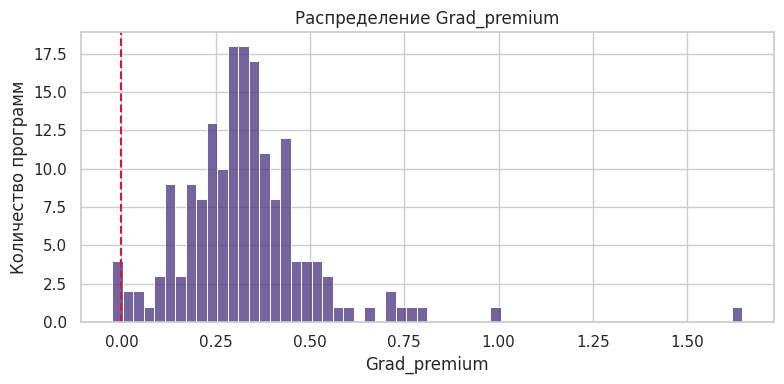

,Major,Grad_median,Nongrad_median,Grad_premium
39,ARCHITECTURAL ENGINEERING,"78,000.0000","80,000.0000",-0.0250
81,MISCELLANEOUS AGRICULTURE,"54,000.0000","55,000.0000",-0.0182
52,PETROLEUM ENGINEERING,"124,000.0000","126,000.0000",-0.0159


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(datasets["majors_degree_levels"]["Grad_premium"], bins=60, ax=ax)
ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5)
ax.set_title("Распределение Grad_premium")
ax.set_xlabel("Grad_premium")
ax.set_ylabel("Количество программ")
plt.tight_layout()
plt.show()

negative_grad_premium = (
    datasets["majors_degree_levels"]
    .loc[
        datasets["majors_degree_levels"]["Grad_premium"] < 0,
        ["Major", "Grad_median", "Nongrad_median", "Grad_premium"],
    ]
    .sort_values("Grad_premium")
)
negative_grad_premium


Отрицательный `Grad_premium` наблюдается у *3 из 173* программ. Замечание следует интерпретировать как интересный факт, а не ошибку в данных.


## Преобразования признаков


### Приведение текстовых идентификаторов к категориальному типу


In [12]:
for df in datasets.values():
    df["Major"] = df["Major"].astype("category")
    df["Major_category"] = df["Major_category"].astype("category")


После преобразований текстовые идентификаторы программ и категорий переведены в тип `category`.


## Сохранение изменений


In [13]:
output_paths = {
    "majors_all_ages": PROCESSED_DATA_DIR / "majors_all_ages_clean.parquet",
    "majors_degree_levels": PROCESSED_DATA_DIR / "majors_degree_levels_clean.parquet",
    "majors_recent_graduates": PROCESSED_DATA_DIR
    / "majors_recent_graduates_clean.parquet",
}

for name, df in datasets.items():
    df.to_parquet(output_paths[name], index=False)


Техническая очистка не потребовала агрессивных правок значений. Основной результат этапа - фиксация единичных аномалий, сохранение обоснованных пропусков и приведение типов к более удобному виду для следующих аналитических шагов.
